# Big Data Analytics for Cyber Threat Detection in Irish Banking — Experiment Notebook
Re-runs `src/pipeline.py` and shows the key tables and figures used in the final report.

Data: Kaggle *Bank Transaction Records along Suspicious Flags* (`data/transactions_Dataset.csv`, download with `kaggle datasets download -d charanmaik/bank-transaction-records-along-suspicious-flags --unzip -p data`).

In [1]:
import sys, json, pandas as pd
from IPython.display import Image, display
sys.path.insert(0, '../src')
import pipeline
pipeline.main()

loaded 33611 rows, 33611 after dedup/dropna


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Logistic Regression  F1=0.9911 AUC=0.9965


Decision Tree        F1=0.9960 AUC=0.9976


Random Forest        F1=0.9960 AUC=0.9971


SVM (RBF)            F1=0.9893 AUC=0.9965


Gradient Boosting    F1=0.9958 AUC=0.9987


Rule baseline        F1=0.9951 (amount > 197,827)


done in 235s; best=Decision Tree


## Dataset summary

In [2]:
print(json.load(open('../results/eda_summary.json')))
pd.read_csv('../results/channel_rates.csv')

{'rows': 33611, 'columns_raw': 6, 'date_min': '2022-12-16', 'date_max': '2025-01-12', 'suspicious': 14203, 'normal': 19408, 'suspicious_rate': 0.4225699919669156, 'unique_descriptions': 43}


,channel,mean,size
0,ATMWITHDRAWAL,0.000000,500
1,CASHDEPOSIT,0.000000,471
2,EMI,0.000000,482
3,FUNDSTRANSFER,0.000000,1116
4,IMPS,0.000000,3003
5,REFUNDOF,0.000000,475
6,REVOFNETTXN,0.000000,506
7,PCA,0.157695,6335
8,NETTXN,0.613628,16070
9,CRYPTOEXCHANGE,0.718461,4653


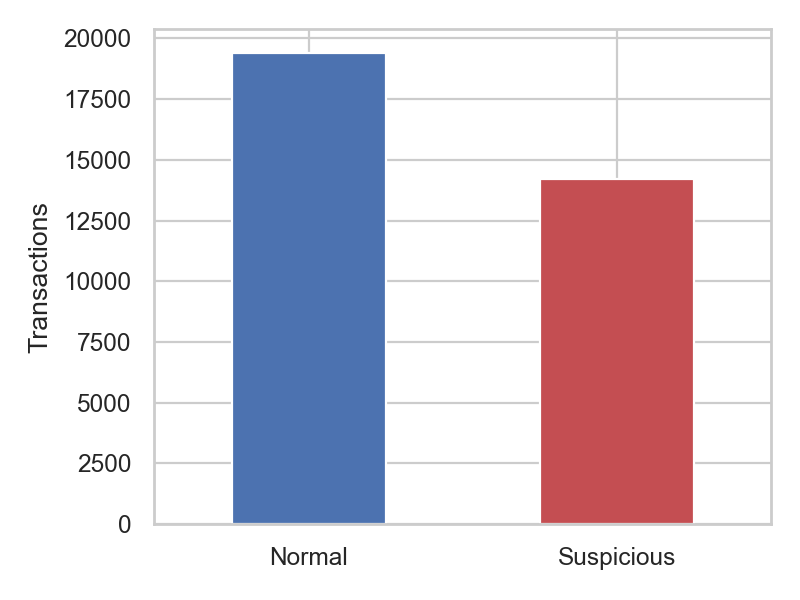

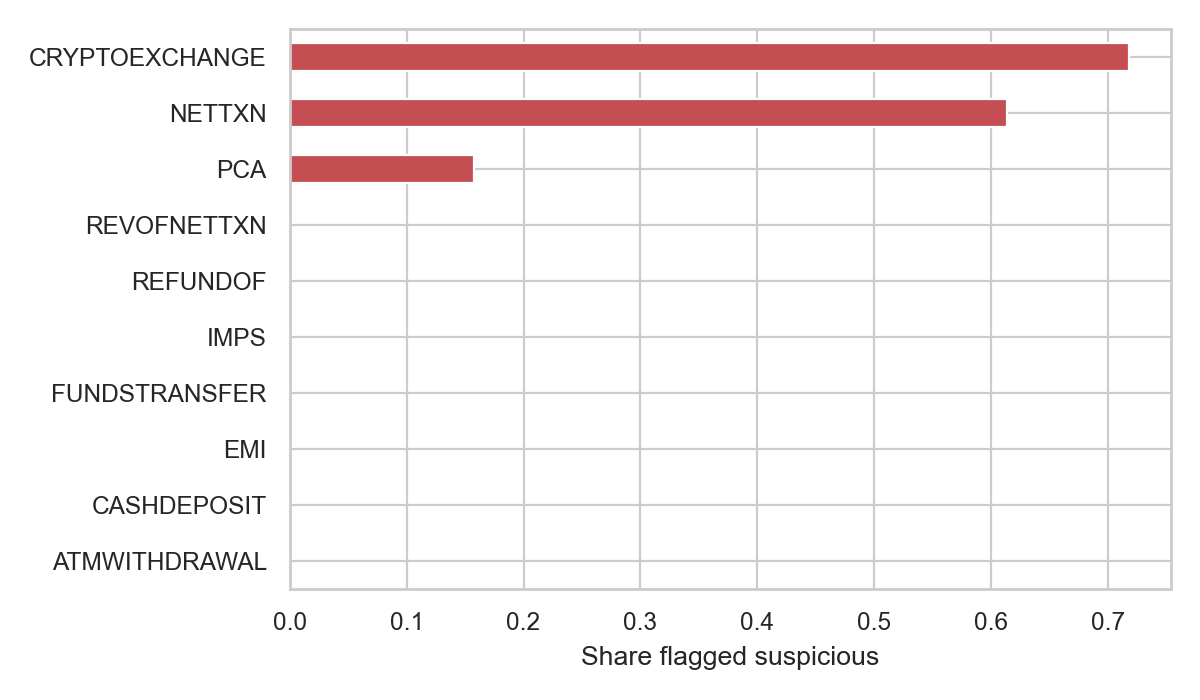

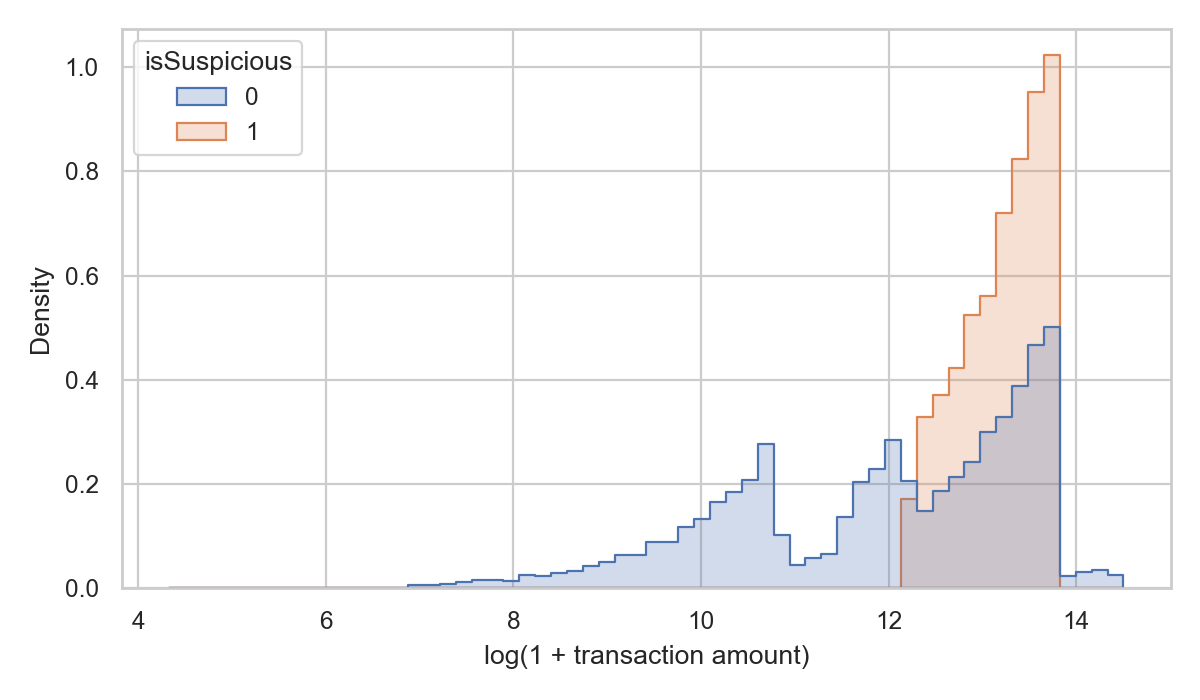

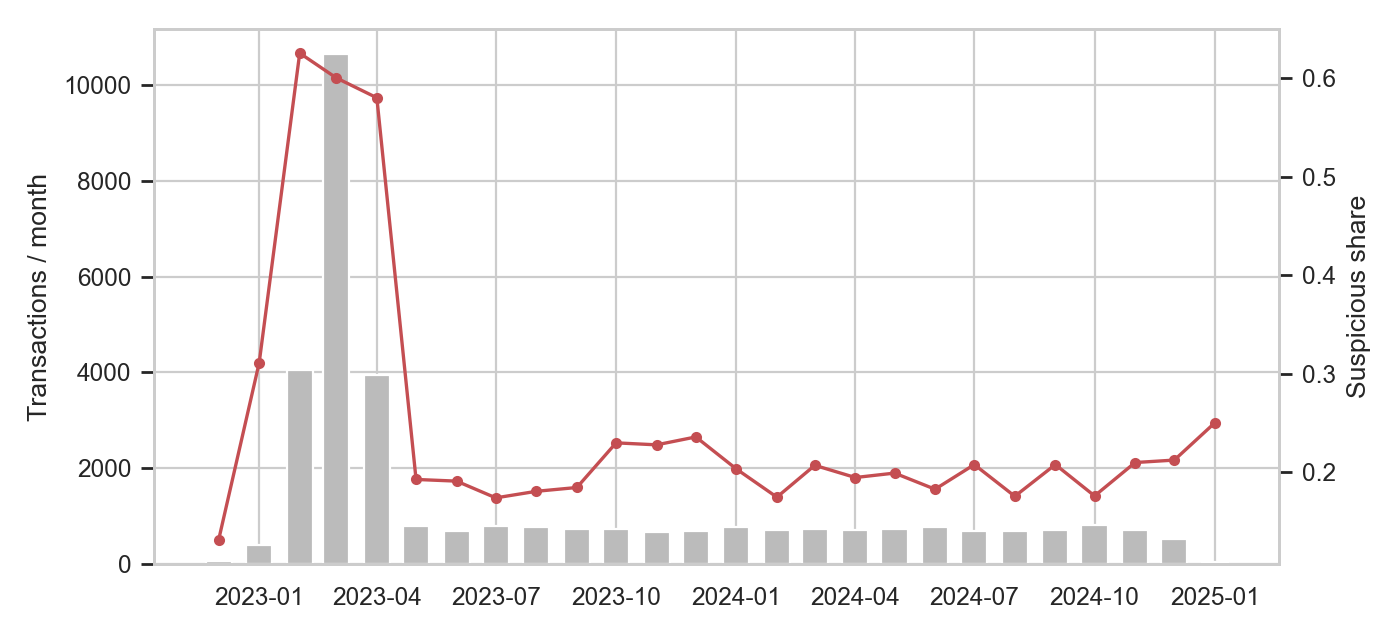

In [3]:
for f in ['class_balance','suspicious_rate_by_channel','amount_distribution','monthly_trend']: display(Image(f'../figures/{f}.png', width=500))

## Model comparison (80:20 hold-out and 5-fold CV)

In [4]:
pd.read_csv('../results/test_results.csv').round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_ci_low,f1_ci_high,tn,fp,fn,tp,fit_seconds,latency_ms_per_txn
0,Decision Tree,0.9966,0.9923,0.9996,0.9960,0.9976,0.9938,0.9942,0.9975,3860,22,1,2840,0.0918,0.0004
1,Random Forest,0.9966,0.9923,0.9996,0.9960,0.9971,0.9938,0.9942,0.9975,3860,22,1,2840,0.4222,0.0044
2,Gradient Boosting,0.9964,0.9916,1.0000,0.9958,0.9987,0.9977,0.9941,0.9973,3858,24,0,2841,2.0917,0.0023
3,Rule baseline,0.9958,0.9902,1.0000,0.9951,0.9964,0.9902,0.9933,0.9967,3854,28,0,2841,0.0000,0.0000
4,Logistic Regression,0.9924,0.9830,0.9993,0.9911,0.9965,0.9913,0.9886,0.9935,3833,49,2,2839,0.0440,0.0007
5,SVM (RBF),0.9909,0.9857,0.9930,0.9893,0.9965,0.9911,0.9866,0.9919,3841,41,20,2821,7.4143,0.0712


In [5]:
pd.read_csv('../results/cv_results.csv').round(4)

,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_sd,precision_sd,recall_sd,f1_sd,roc_auc_sd
0,Logistic Regression,0.9914,0.9802,1.0000,0.9900,0.9971,0.0012,0.0028,0.0000,0.0014,0.0009
1,Decision Tree,0.9969,0.9928,0.9999,0.9963,0.9980,0.0010,0.0023,0.0002,0.0012,0.0007
2,Random Forest,0.9969,0.9928,0.9999,0.9963,0.9972,0.0010,0.0023,0.0002,0.0012,0.0009
3,SVM (RBF),0.9893,0.9801,0.9949,0.9874,0.9971,0.0005,0.0016,0.0008,0.0006,0.0009
4,Gradient Boosting,0.9959,0.9913,0.9992,0.9952,0.9983,0.0008,0.0017,0.0006,0.0010,0.0005


In [6]:
pd.read_csv('../results/mcnemar.csv')

,best,other,best_only_correct,other_only_correct,statistic,p_value
0,Decision Tree,Logistic Regression,29,1,1.0,5.774200e-08
1,Decision Tree,Random Forest,0,0,0.0,1.000000e+00
2,Decision Tree,SVM (RBF),39,1,1.0,7.457857e-11
3,Decision Tree,Gradient Boosting,2,1,1.0,1.000000e+00


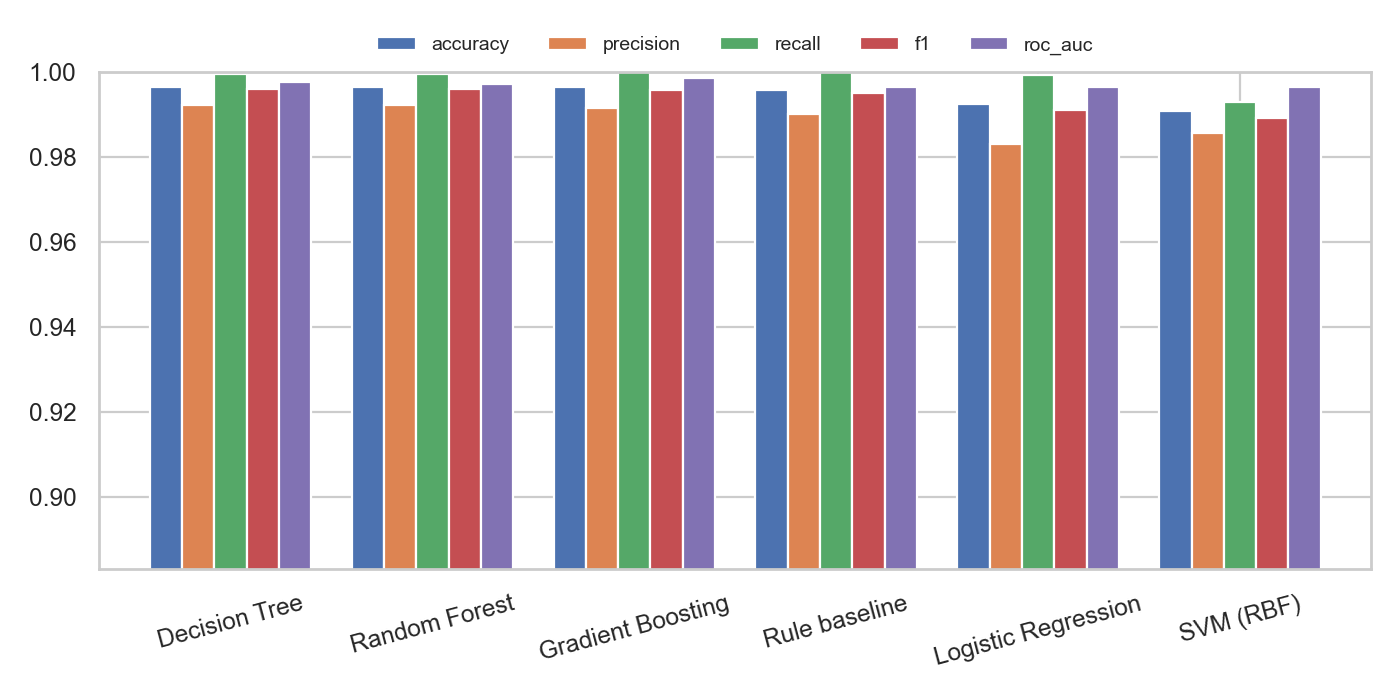

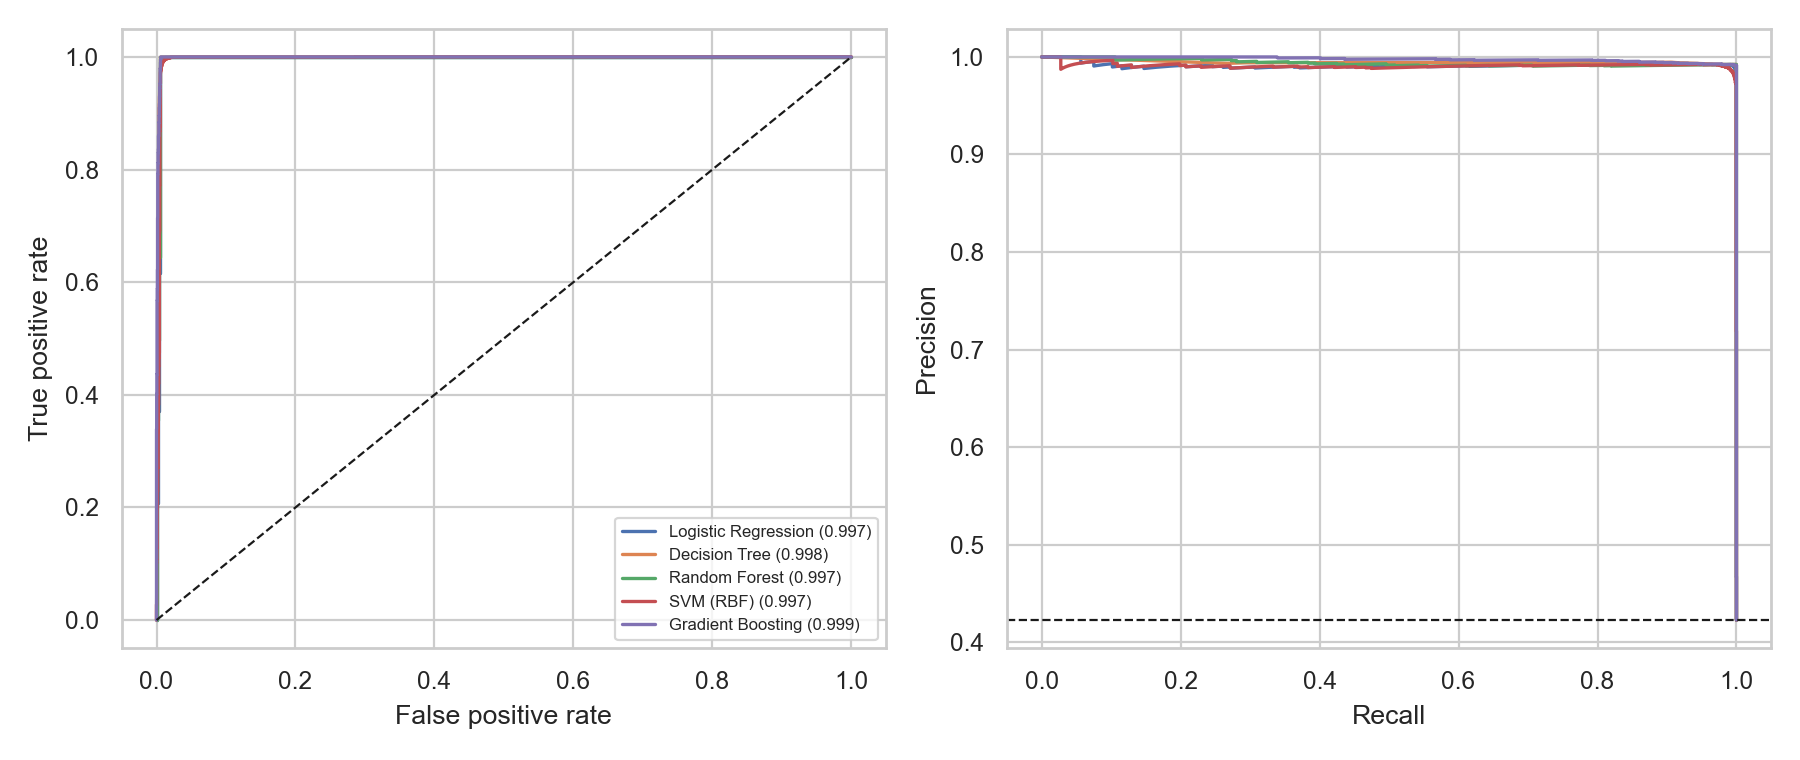

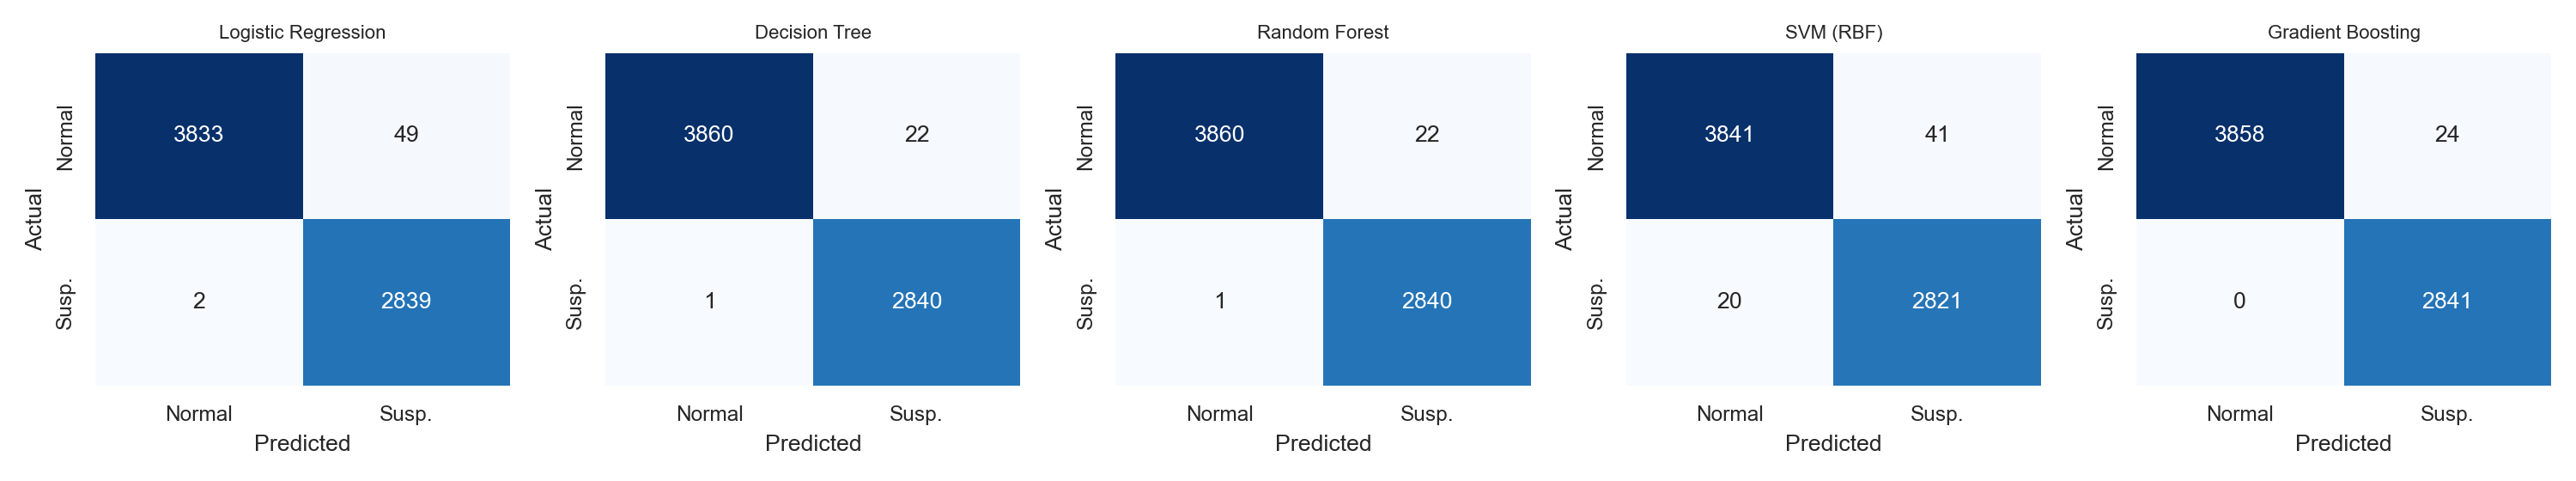

In [7]:
for f in ['model_comparison','roc_pr_curves','confusion_matrices']: display(Image(f'../figures/{f}.png', width=700))

## Robustness: ablation, imbalance, temporal split, unseen merchants

In [8]:
for f in ['ablation','imbalance','temporal_split','unseen_merchant']: display(pd.read_csv(f'../results/{f}.csv').round(4))

,feature_set,accuracy,precision,recall,f1,roc_auc,pr_auc
0,All features,0.9966,0.9923,0.9996,0.9960,0.9971,0.9938
1,Without description/channel,0.8343,0.8160,0.7849,0.8001,0.8904,0.8047
2,Without date features,0.9966,0.9923,0.9996,0.9960,0.9976,0.9938
3,Description/channel only,0.8376,0.7223,1.0000,0.8388,0.8615,0.7255
4,Amount & balance only,0.7172,0.6020,0.9761,0.7447,0.7718,0.6318


,strategy,accuracy,precision,recall,f1,roc_auc,pr_auc
0,No re-balancing,0.9966,0.9923,0.9996,0.996,0.9973,0.9931
1,Class weights,0.9966,0.9923,0.9996,0.996,0.9973,0.9939
2,SMOTE,0.9966,0.9923,0.9996,0.996,0.9971,0.9923


,model,feature_set,train_until,test_from,test_suspicious_rate,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Decision Tree,All features,2024-03-16,2024-03-17,0.196,0.9997,1.0000,0.9985,0.9992,1.0000,1.0000
1,Decision Tree,Without date features,2024-03-16,2024-03-17,0.196,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,All features,2024-03-16,2024-03-17,0.196,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,Random Forest,Without date features,2024-03-16,2024-03-17,0.196,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,SVM (RBF),All features,2024-03-16,2024-03-17,0.196,0.9503,0.9960,0.7496,0.8554,0.9988,0.9950
5,SVM (RBF),Without date features,2024-03-16,2024-03-17,0.196,0.9976,0.9947,0.9932,0.9939,1.0000,0.9999
6,Gradient Boosting,All features,2024-03-16,2024-03-17,0.196,0.9999,1.0000,0.9992,0.9996,1.0000,1.0000
7,Gradient Boosting,Without date features,2024-03-16,2024-03-17,0.196,0.9999,1.0000,0.9992,0.9996,1.0000,1.0000


,model,accuracy,precision,recall,f1,roc_auc,f1_sd
0,Decision Tree,0.8850,0.8436,0.8787,0.8584,0.9629,0.0459
1,Random Forest,0.8988,0.8778,0.8677,0.8694,0.9735,0.0502
2,SVM (RBF),0.8836,0.8416,0.8800,0.8573,0.9528,0.0400
3,Gradient Boosting,0.9073,0.9018,0.8618,0.8776,0.9741,0.0528


## Explainability and operations

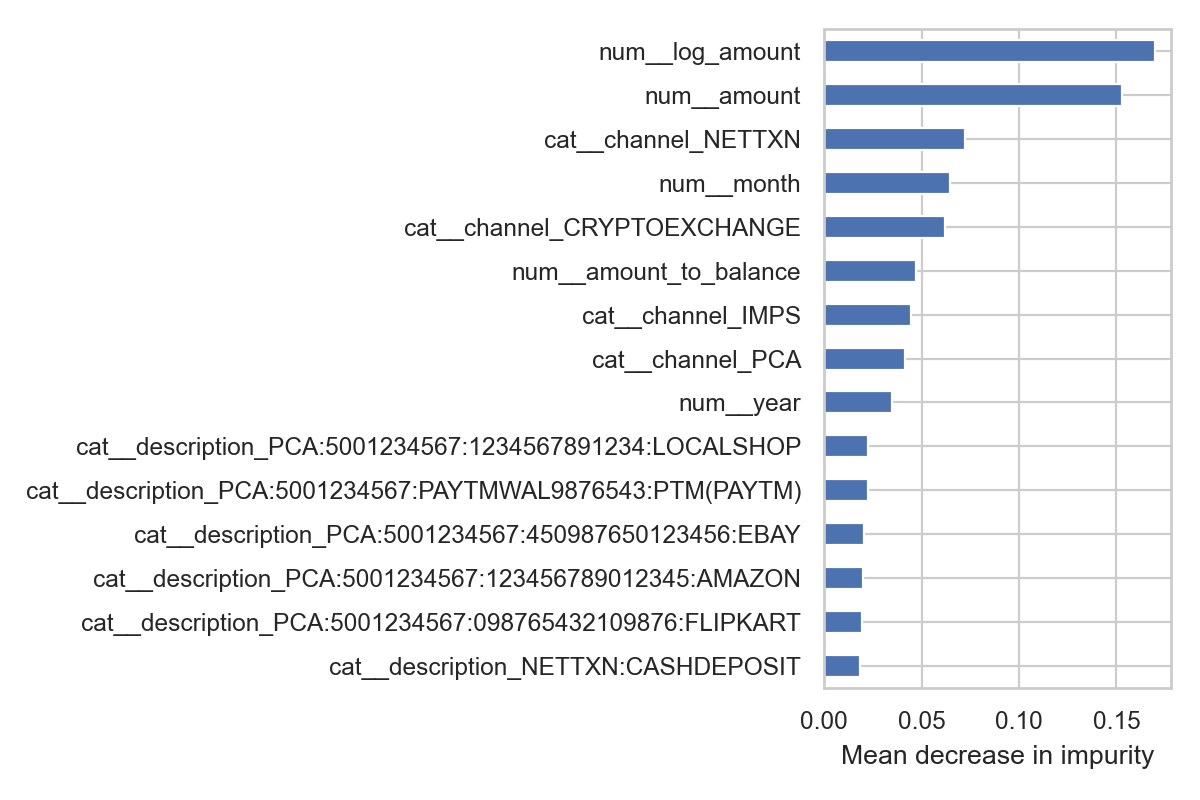

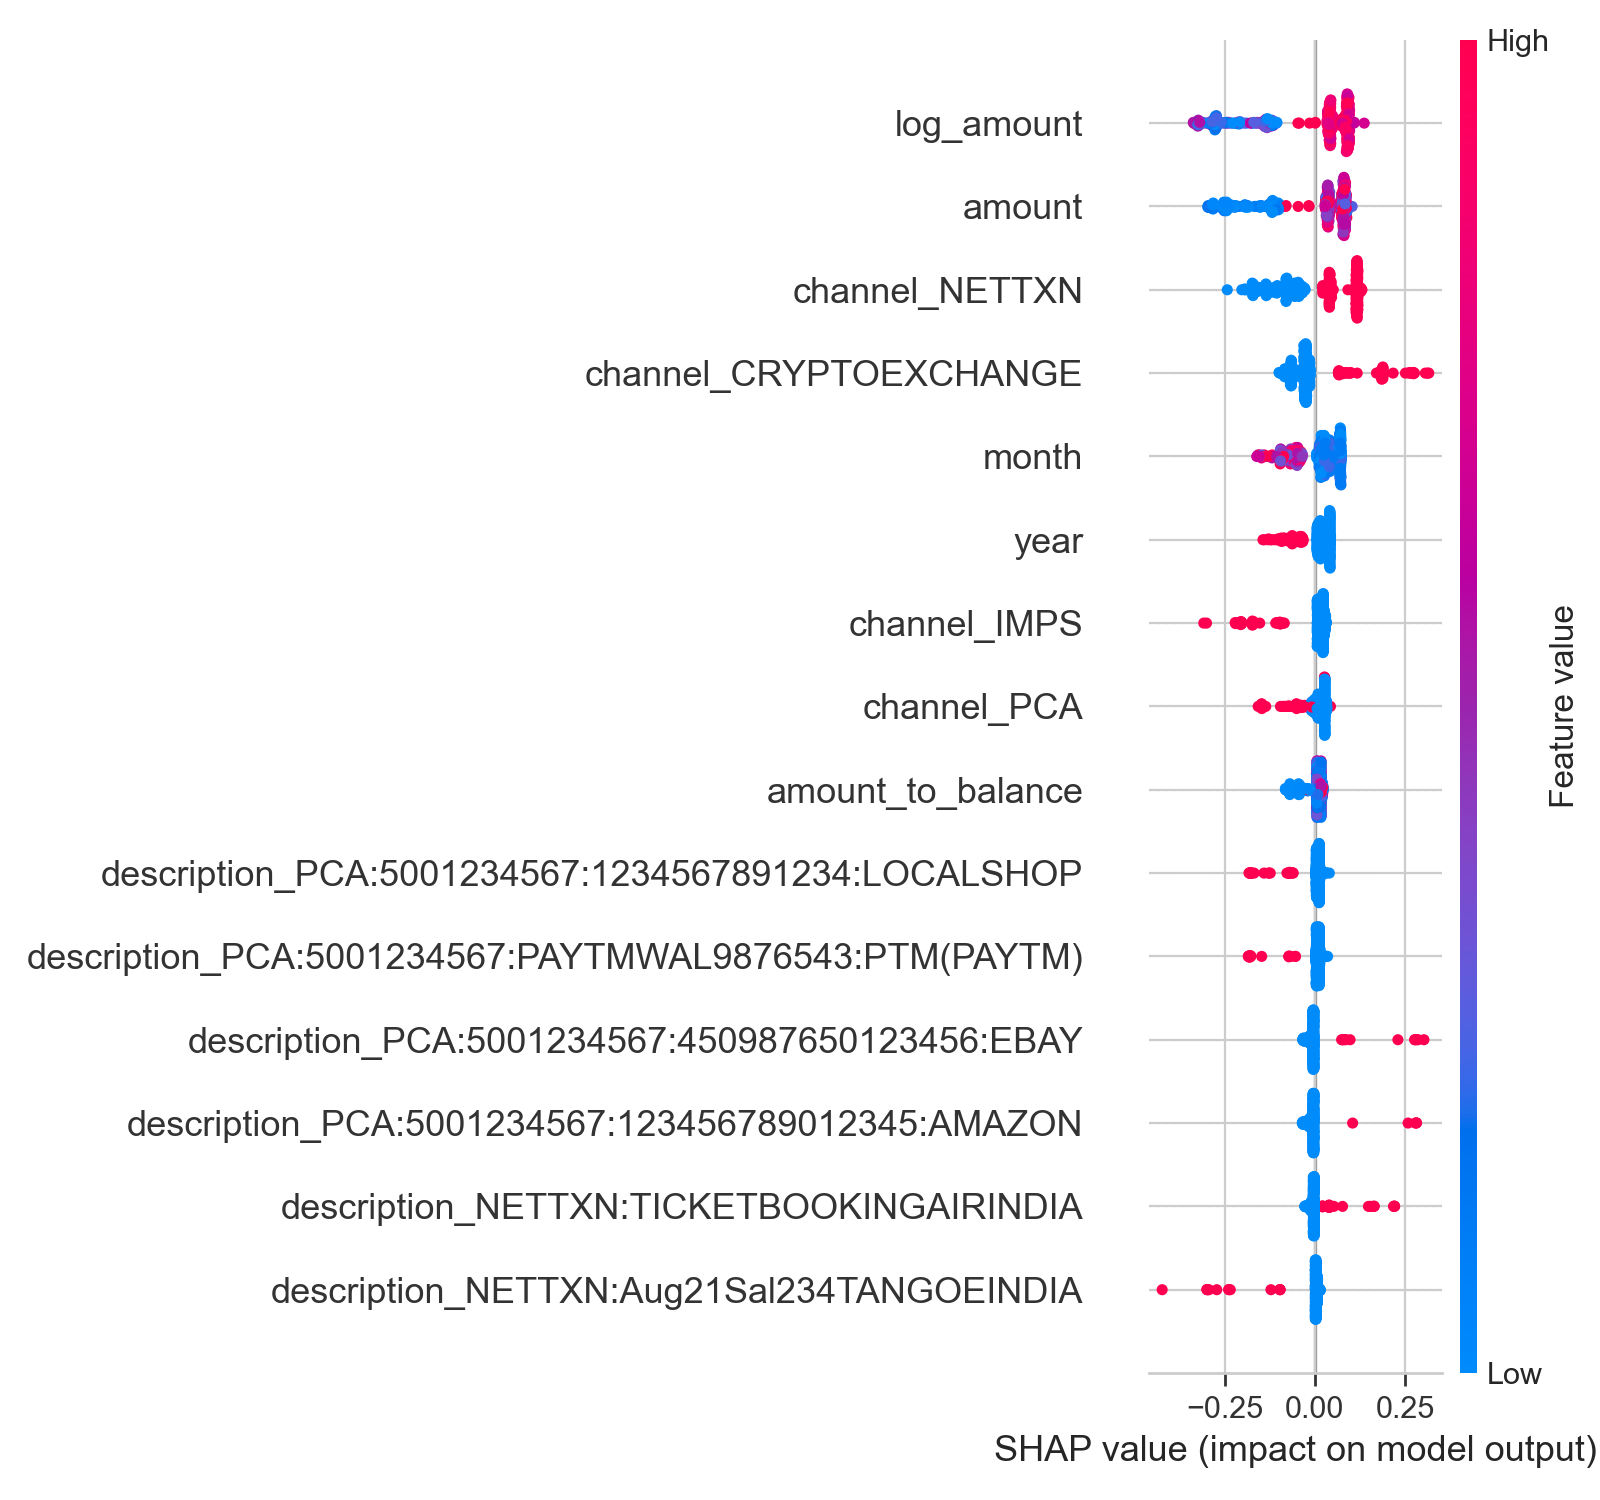

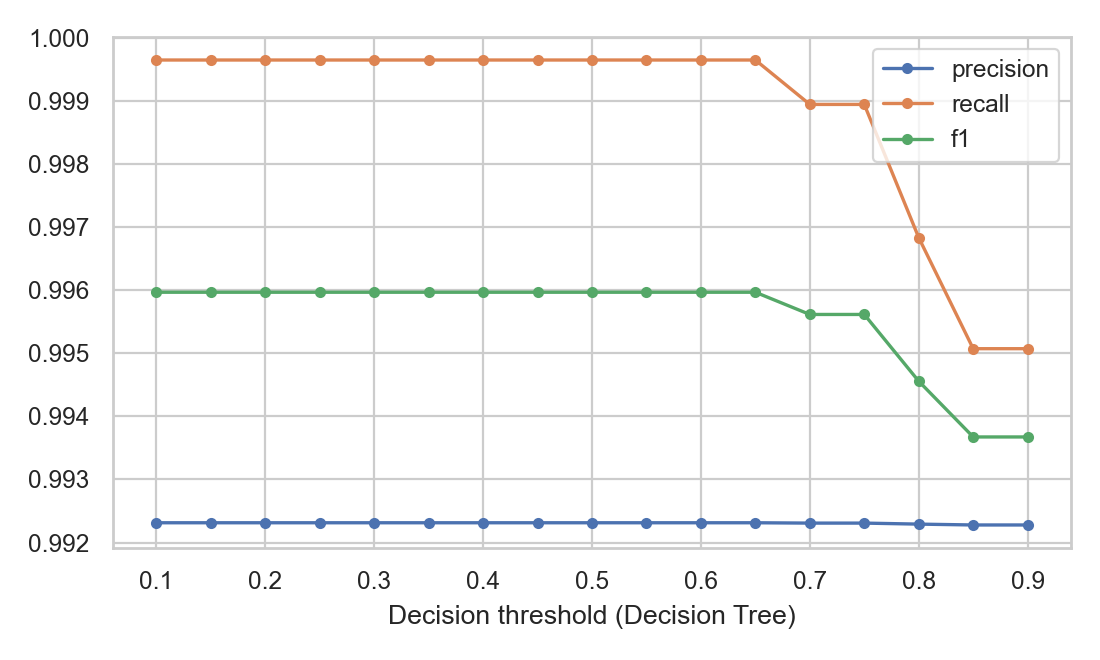

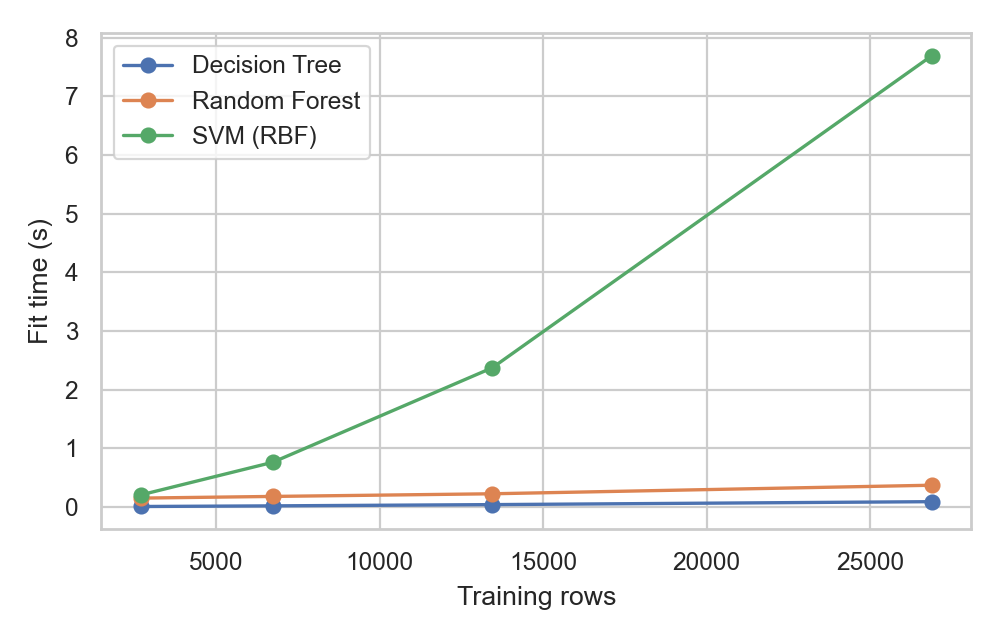

In [9]:
for f in ['rf_feature_importance','shap_summary','threshold_tradeoff','scalability']: display(Image(f'../figures/{f}.png', width=550))